In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load predictions
df = pd.read_csv("split4_predictions.csv")

1. training & validation loss 

In [2]:
import torch

ckpt = torch.load("20260314_095407_HierarchicalAttnMIL_epoch12.pth", map_location="cpu")

print(type(ckpt))
print(ckpt.keys() if isinstance(ckpt, dict) else "Not a dict")

<class 'dict'>
dict_keys(['arch', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'train_losses', 'train_ce_losses', 'train_patch_entropy_losses', 'val_losses', 'val_accuracies', 'learning_rates', 'best_val_loss', 'config', 'scheduler_state_dict'])


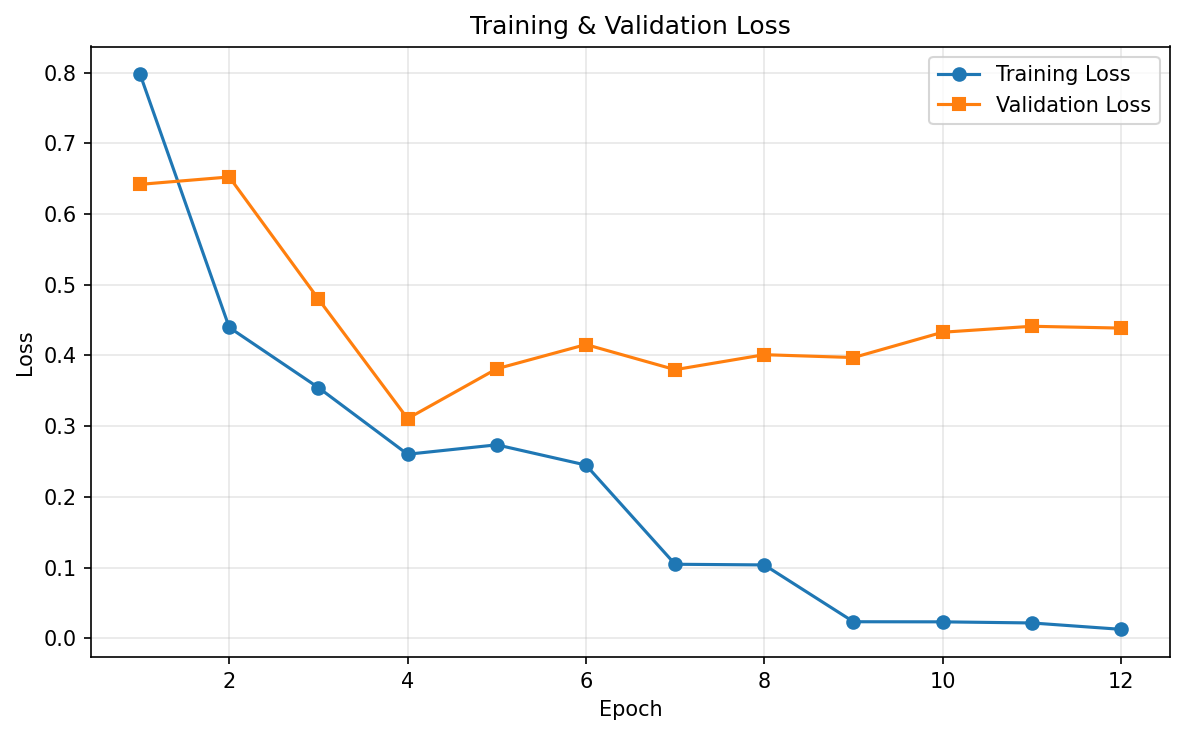

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# load checkpoint
ckpt = torch.load("20260314_095407_HierarchicalAttnMIL_epoch12.pth", map_location="cpu")

train_losses = ckpt["train_losses"]
val_losses = ckpt["val_losses"]

epochs = np.arange(1, len(train_losses)+1)

# plot
plt.figure(figsize=(8,5), dpi=150)

plt.plot(epochs, train_losses, marker='o', label="Training Loss")
plt.plot(epochs, val_losses, marker='s', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


2) confusion matrix 

In [4]:
print(df.columns)

Index(['case_id', 'true_label', 'predicted_label', 'correct', 'prob_class0',
       'prob_class1'],
      dtype='object')


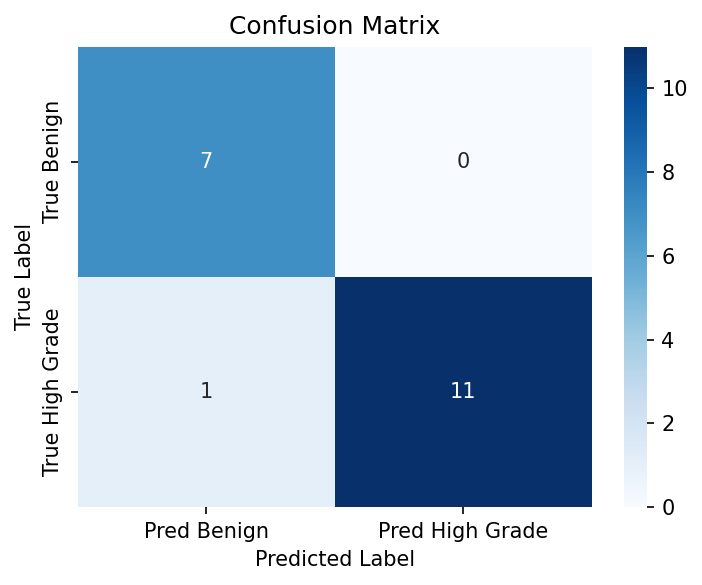

In [5]:
# confusion matrix 
threshold = 0.5
df["pred_label"] = (df["prob_class1"] >= threshold).astype(int)

cm = confusion_matrix(df["true_label"], df["pred_label"])

plt.figure(figsize=(5,4), dpi=150)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Benign", "Pred High Grade"],
    yticklabels=["True Benign", "True High Grade"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

3) deviation plot (true vs probabilities)


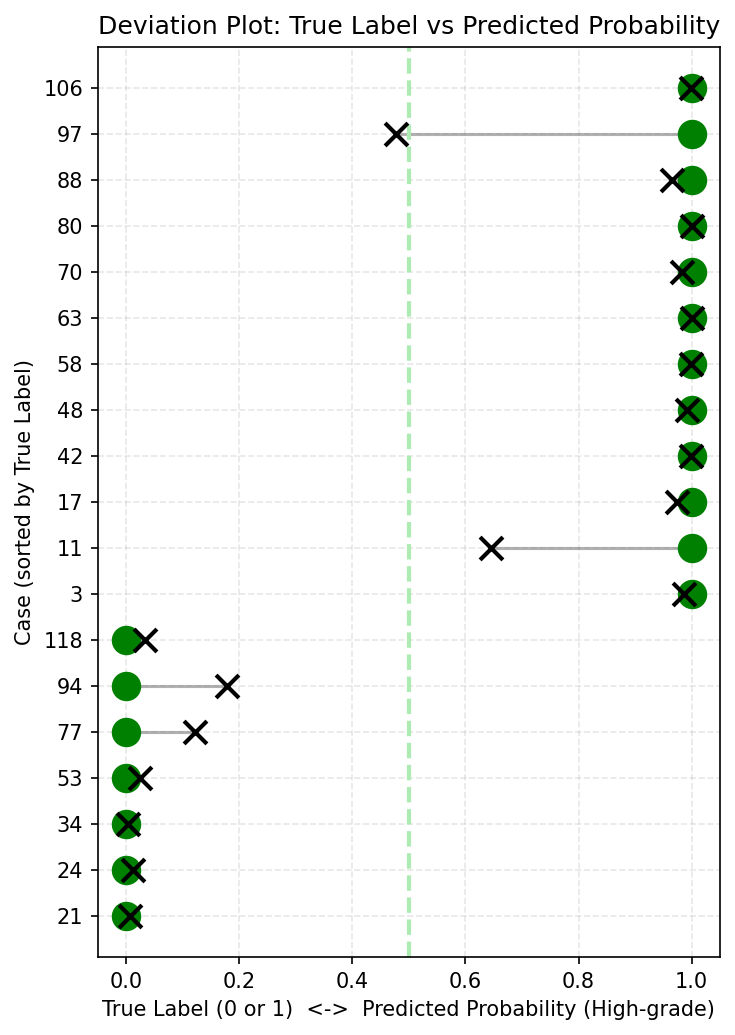

In [6]:
# Sort so true=0 cases appear first (optional but cleaner)
df_sorted = df.sort_values(["true_label", "case_id"]).reset_index(drop=True)
df_sorted["case_str"] = df_sorted["case_id"].astype(str)

plt.figure(figsize=(5,7), dpi=150)

for i, row in df_sorted.iterrows():
    # connecting line
    plt.plot(
        [row["true_label"], row["prob_class1"]],
        [i, i],
        color="gray",
        alpha=0.6,
        linewidth=1.5
    )

    # true label = large green circle
    plt.scatter(
        row["true_label"], i,
        color="green",
        s=200,
        marker="o",
        edgecolor="black",
        linewidth=0,
        zorder=3
    )

    # predicted probability = small black X
    plt.scatter(
        row["prob_class1"], i,
        color="black",
        s=120,
        marker="x",
        linewidths=2,
        zorder=4
    )

plt.yticks(range(len(df_sorted)), df_sorted["case_str"])
plt.axvline(0.5, color="#ADEBB3", linestyle="--", linewidth=2, label="Decision Threshold (0.5)")
plt.xlabel("True Label (0 or 1)  <->  Predicted Probability (High-grade)")
plt.ylabel("Case (sorted by True Label)")
plt.title("Deviation Plot: True Label vs Predicted Probability")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()
